In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dfTrain = pd.read_csv('/content/drive/MyDrive/HCI Dataset/home-credit-default-risk/application_train.csv')
dfTest = pd.read_csv('/content/drive/MyDrive/HCI Dataset/home-credit-default-risk/application_test.csv')

dfRaw = pd.concat([dfTrain,dfTest], axis = 0)
dfRaw.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
dfRaw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356255 entries, 0 to 48743
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(66), int64(40), object(16)
memory usage: 334.3+ MB


In [ ]:
dfRaw = dfRaw.reset_index(drop=True)

In [ ]:
dfRaw.info(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        float64
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [ ]:
for i in range(24):
    k = 25
    j = 50
    l = 75
    m = 100
    if i>= 0 and i < 25:
        print(f"column {i} : {dfRaw.columns[i]}", end= "\t\t ")
        if i+k >= 25 and i+k < 50:
            print(f"column {i+k} : {dfRaw.columns[i+k]}", end= "\t\t")
            if i+j >= 50 and i+j < 75:
                print(f"column {i+j} : {dfRaw.columns[i+j]}", end= "\t\t ")
                if i+l >= 75 and i+l < 100:
                    print(f"column {i+l} : {dfRaw.columns[i+l]}", end= "\t\t ")
                    if i+m >= 100 and i+m < 121:
                        print(f"column {i+m} : {dfRaw.columns[i+m]}", end= "\t\t ")

    print("")
    print("")


# print(dfRaw.columns[0])

column 0 : SK_ID_CURR		 column 25 : FLAG_CONT_MOBILE		column 50 : ENTRANCES_AVG		 column 75 : YEARS_BUILD_MEDI		 column 100 : FLAG_DOCUMENT_6		 

column 1 : TARGET		 column 26 : FLAG_PHONE		column 51 : FLOORSMAX_AVG		 column 76 : COMMONAREA_MEDI		 column 101 : FLAG_DOCUMENT_7		 

column 2 : NAME_CONTRACT_TYPE		 column 27 : FLAG_EMAIL		column 52 : FLOORSMIN_AVG		 column 77 : ELEVATORS_MEDI		 column 102 : FLAG_DOCUMENT_8		 

column 3 : CODE_GENDER		 column 28 : OCCUPATION_TYPE		column 53 : LANDAREA_AVG		 column 78 : ENTRANCES_MEDI		 column 103 : FLAG_DOCUMENT_9		 

column 4 : FLAG_OWN_CAR		 column 29 : CNT_FAM_MEMBERS		column 54 : LIVINGAPARTMENTS_AVG		 column 79 : FLOORSMAX_MEDI		 column 104 : FLAG_DOCUMENT_10		 

column 5 : FLAG_OWN_REALTY		 column 30 : REGION_RATING_CLIENT		column 55 : LIVINGAREA_AVG		 column 80 : FLOORSMIN_MEDI		 column 105 : FLAG_DOCUMENT_11		 

column 6 : CNT_CHILDREN		 column 31 : REGION_RATING_CLIENT_W_CITY		column 56 : NONLIVINGAPARTMENTS_AVG		 column 81 : LANDA

In [ ]:
temp = dfRaw.isnull().sum()
print(temp)

SK_ID_CURR                        0
TARGET                        48744
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     47568
AMT_REQ_CREDIT_BUREAU_WEEK    47568
AMT_REQ_CREDIT_BUREAU_MON     47568
AMT_REQ_CREDIT_BUREAU_QRT     47568
AMT_REQ_CREDIT_BUREAU_YEAR    47568
Length: 122, dtype: int64


In [ ]:
countColNum = 0
for label,i in temp.items():
    if i != 0:
        countColNum = countColNum + 1
        print(f"{label} : {i}")

print(f"Jumlah kolom yang kosong : {countColNum}")

TARGET : 48744
AMT_ANNUITY : 36
AMT_GOODS_PRICE : 278
NAME_TYPE_SUITE : 2203
OWN_CAR_AGE : 235241
OCCUPATION_TYPE : 111996
CNT_FAM_MEMBERS : 2
EXT_SOURCE_1 : 193910
EXT_SOURCE_2 : 668
EXT_SOURCE_3 : 69633
APARTMENTS_AVG : 179948
BASEMENTAREA_AVG : 207584
YEARS_BEGINEXPLUATATION_AVG : 172863
YEARS_BUILD_AVG : 236306
COMMONAREA_AVG : 248360
ELEVATORS_AVG : 189080
ENTRANCES_AVG : 178407
FLOORSMAX_AVG : 176341
FLOORSMIN_AVG : 241108
LANDAREA_AVG : 210844
LIVINGAPARTMENTS_AVG : 242979
LIVINGAREA_AVG : 177902
NONLIVINGAPARTMENTS_AVG : 246861
NONLIVINGAREA_AVG : 195766
APARTMENTS_MODE : 179948
BASEMENTAREA_MODE : 207584
YEARS_BEGINEXPLUATATION_MODE : 172863
YEARS_BUILD_MODE : 236306
COMMONAREA_MODE : 248360
ELEVATORS_MODE : 189080
ENTRANCES_MODE : 178407
FLOORSMAX_MODE : 176341
FLOORSMIN_MODE : 241108
LANDAREA_MODE : 210844
LIVINGAPARTMENTS_MODE : 242979
LIVINGAREA_MODE : 177902
NONLIVINGAPARTMENTS_MODE : 246861
NONLIVINGAREA_MODE : 195766
APARTMENTS_MEDI : 179948
BASEMENTAREA_MEDI : 207584
Y

In [ ]:
dfRaw = dfRaw.dropna(subset = 'TARGET')
temp = dfRaw.isnull().sum()
print(temp)

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64


In [ ]:
countColNum = 0
for label,i in temp.items():
    if i != 0:
        countColNum = countColNum + 1
        print(f"{label} : {i}")

print(f"Jumlah kolom yang kosong : {countColNum}")

AMT_ANNUITY : 12
AMT_GOODS_PRICE : 278
NAME_TYPE_SUITE : 1292
OWN_CAR_AGE : 202929
OCCUPATION_TYPE : 96391
CNT_FAM_MEMBERS : 2
EXT_SOURCE_1 : 173378
EXT_SOURCE_2 : 660
EXT_SOURCE_3 : 60965
APARTMENTS_AVG : 156061
BASEMENTAREA_AVG : 179943
YEARS_BEGINEXPLUATATION_AVG : 150007
YEARS_BUILD_AVG : 204488
COMMONAREA_AVG : 214865
ELEVATORS_AVG : 163891
ENTRANCES_AVG : 154828
FLOORSMAX_AVG : 153020
FLOORSMIN_AVG : 208642
LANDAREA_AVG : 182590
LIVINGAPARTMENTS_AVG : 210199
LIVINGAREA_AVG : 154350
NONLIVINGAPARTMENTS_AVG : 213514
NONLIVINGAREA_AVG : 169682
APARTMENTS_MODE : 156061
BASEMENTAREA_MODE : 179943
YEARS_BEGINEXPLUATATION_MODE : 150007
YEARS_BUILD_MODE : 204488
COMMONAREA_MODE : 214865
ELEVATORS_MODE : 163891
ENTRANCES_MODE : 154828
FLOORSMAX_MODE : 153020
FLOORSMIN_MODE : 208642
LANDAREA_MODE : 182590
LIVINGAPARTMENTS_MODE : 210199
LIVINGAREA_MODE : 154350
NONLIVINGAPARTMENTS_MODE : 213514
NONLIVINGAREA_MODE : 169682
APARTMENTS_MEDI : 156061
BASEMENTAREA_MEDI : 179943
YEARS_BEGINEXPLUA

In [ ]:
dfRaw.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
dfRaw.info(10)

<class 'pandas.core.frame.DataFrame'>
Index: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        float64
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DAYS_EM

In [ ]:
dfRaw['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts()

,count
AMT_REQ_CREDIT_BUREAU_YEAR,
0.0,71801
1.0,63405
2.0,50192
3.0,33628
4.0,20714
5.0,12052
6.0,6967
7.0,3869
8.0,2127


In [ ]:
dfCleanColumn = dfRaw[["TARGET",
                    "NAME_CONTRACT_TYPE",
                    "CODE_GENDER",
                    "FLAG_OWN_CAR",
                    "FLAG_OWN_REALTY",
                    "CNT_CHILDREN",
                    "AMT_INCOME_TOTAL",
                    "AMT_CREDIT",
                    "AMT_ANNUITY",
                    "AMT_GOODS_PRICE",
                    "NAME_INCOME_TYPE",
                    "NAME_EDUCATION_TYPE",
                    "NAME_FAMILY_STATUS",
                    "NAME_HOUSING_TYPE",
                    "DAYS_BIRTH",
                    "OCCUPATION_TYPE",
                    "CNT_FAM_MEMBERS",
                    "WEEKDAY_APPR_PROCESS_START",
                    "HOUR_APPR_PROCESS_START",
                    "ORGANIZATION_TYPE"]]
dfCleanColumn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307511 entries, 0 to 307510
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      307511 non-null  float64
 1   NAME_CONTRACT_TYPE          307511 non-null  object 
 2   CODE_GENDER                 307511 non-null  object 
 3   FLAG_OWN_CAR                307511 non-null  object 
 4   FLAG_OWN_REALTY             307511 non-null  object 
 5   CNT_CHILDREN                307511 non-null  int64  
 6   AMT_INCOME_TOTAL            307511 non-null  float64
 7   AMT_CREDIT                  307511 non-null  float64
 8   AMT_ANNUITY                 307499 non-null  float64
 9   AMT_GOODS_PRICE             307233 non-null  float64
 10  NAME_INCOME_TYPE            307511 non-null  object 
 11  NAME_EDUCATION_TYPE         307511 non-null  object 
 12  NAME_FAMILY_STATUS          307511 non-null  object 
 13  NAME_HOUSING_TYPE  

In [ ]:
dfCleanColumn.isnull().sum()

,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,12
AMT_GOODS_PRICE,278


In [ ]:
dfCleanColumn.dropna(inplace=True)
dfCleanColumn.isnull().sum()

<ipython-input-24-f055c8f26767>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfCleanColumn.dropna(inplace=True)


,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,0
AMT_GOODS_PRICE,0


In [ ]:
dfCleanColumn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 210887 entries, 0 to 307510
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      210887 non-null  float64
 1   NAME_CONTRACT_TYPE          210887 non-null  object 
 2   CODE_GENDER                 210887 non-null  object 
 3   FLAG_OWN_CAR                210887 non-null  object 
 4   FLAG_OWN_REALTY             210887 non-null  object 
 5   CNT_CHILDREN                210887 non-null  int64  
 6   AMT_INCOME_TOTAL            210887 non-null  float64
 7   AMT_CREDIT                  210887 non-null  float64
 8   AMT_ANNUITY                 210887 non-null  float64
 9   AMT_GOODS_PRICE             210887 non-null  float64
 10  NAME_INCOME_TYPE            210887 non-null  object 
 11  NAME_EDUCATION_TYPE         210887 non-null  object 
 12  NAME_FAMILY_STATUS          210887 non-null  object 
 13  NAME_HOUSING_TYPE  

In [ ]:
dfCleanColumn.drop_duplicates(inplace=True)
dfCleanColumn.info()

<ipython-input-26-fd227f221537>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfCleanColumn.drop_duplicates(inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 210881 entries, 0 to 307510
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      210881 non-null  float64
 1   NAME_CONTRACT_TYPE          210881 non-null  object 
 2   CODE_GENDER                 210881 non-null  object 
 3   FLAG_OWN_CAR                210881 non-null  object 
 4   FLAG_OWN_REALTY             210881 non-null  object 
 5   CNT_CHILDREN                210881 non-null  int64  
 6   AMT_INCOME_TOTAL            210881 non-null  float64
 7   AMT_CREDIT                  210881 non-null  float64
 8   AMT_ANNUITY                 210881 non-null  float64
 9   AMT_GOODS_PRICE             210881 non-null  float64
 10  NAME_INCOME_TYPE            210881 non-null  object 
 11  NAME_EDUCATION_TYPE         210881 non-null  object 
 12  NAME_FAMILY_STATUS          210881 non-null  object 
 13  NAME_HOUSING_TYPE  

In [ ]:
dfCleanColumn.reset_index(drop = True, inplace= True)
dfCleanColumn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210881 entries, 0 to 210880
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      210881 non-null  float64
 1   NAME_CONTRACT_TYPE          210881 non-null  object 
 2   CODE_GENDER                 210881 non-null  object 
 3   FLAG_OWN_CAR                210881 non-null  object 
 4   FLAG_OWN_REALTY             210881 non-null  object 
 5   CNT_CHILDREN                210881 non-null  int64  
 6   AMT_INCOME_TOTAL            210881 non-null  float64
 7   AMT_CREDIT                  210881 non-null  float64
 8   AMT_ANNUITY                 210881 non-null  float64
 9   AMT_GOODS_PRICE             210881 non-null  float64
 10  NAME_INCOME_TYPE            210881 non-null  object 
 11  NAME_EDUCATION_TYPE         210881 non-null  object 
 12  NAME_FAMILY_STATUS          210881 non-null  object 
 13  NAME_HOUSING_T

In [ ]:
dfCleanColumn.to_csv("cleanDataset.csv", index=False)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in dfCleanColumn.columns:
    if dfCleanColumn[col].dtype == 'object':
        dfCleanColumn[col] = le.fit_transform(dfCleanColumn[col])

<ipython-input-21-73cee0ecbff5>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfCleanColumn[col] = le.fit_transform(dfCleanColumn[col])
<ipython-input-21-73cee0ecbff5>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfCleanColumn[col] = le.fit_transform(dfCleanColumn[col])
<ipython-input-21-73cee0ecbff5>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

In [ ]:
dfCleanColumn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210881 entries, 0 to 210880
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      210881 non-null  float64
 1   NAME_CONTRACT_TYPE          210881 non-null  int64  
 2   CODE_GENDER                 210881 non-null  int64  
 3   FLAG_OWN_CAR                210881 non-null  int64  
 4   FLAG_OWN_REALTY             210881 non-null  int64  
 5   CNT_CHILDREN                210881 non-null  int64  
 6   AMT_INCOME_TOTAL            210881 non-null  float64
 7   AMT_CREDIT                  210881 non-null  float64
 8   AMT_ANNUITY                 210881 non-null  float64
 9   AMT_GOODS_PRICE             210881 non-null  float64
 10  NAME_INCOME_TYPE            210881 non-null  int64  
 11  NAME_EDUCATION_TYPE         210881 non-null  int64  
 12  NAME_FAMILY_STATUS          210881 non-null  int64  
 13  NAME_HOUSING_T

In [ ]:
dfCleanColumn.describe()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,OCCUPATION_TYPE,CNT_FAM_MEMBERS,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,ORGANIZATION_TYPE
count,210881.000000,210881.000000,210881.000000,210881.000000,210881.000000,210881.000000,2.108810e+05,2.108810e+05,210881.000000,2.108810e+05,210881.000000,210881.000000,210881.000000,210881.000000,210881.000000,210881.000000,210881.000000,210881.000000,210881.000000,210881.000000
mean,0.087865,0.101797,0.387688,0.380186,0.680075,0.502919,1.758159e+05,6.106497e+05,27807.242461,5.481853e+05,4.424547,3.144750,1.343227,1.336778,-14764.718519,7.850603,2.260763,3.086409,12.187058,24.142867
std,0.283099,0.302382,0.487243,0.485434,0.466448,0.764343,2.752799e+05,4.057793e+05,14619.271298,3.723517e+05,2.210447,1.320351,0.946404,1.026752,3643.500296,4.400079,0.941172,2.143442,3.295615,17.604341
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1980.000000,4.050000e+04,0.000000,0.000000,0.000000,0.000000,-25200.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.125000e+05,2.779695e+05,17095.500000,2.475000e+05,1.000000,1.000000,1.000000,1.000000,-17542.000000,4.000000,2.000000,1.000000,10.000000,5.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.575000e+05,5.212800e+05,25843.500000,4.500000e+05,6.000000,4.000000,1.000000,1.000000,-14576.000000,8.000000,2.000000,4.000000,12.000000,28.000000
75%,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.115000e+05,8.248230e+05,35613.000000,6.885000e+05,6.000000,4.000000,1.000000,1.000000,-11790.000000,11.000000,3.000000,5.000000,15.000000,42.000000
max,1.000000,1.000000,2.000000,1.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,6.000000,4.000000,4.000000,5.000000,-7489.000000,17.000000,20.000000,6.000000,23.000000,56.000000


In [ ]:
dfCleanColumn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210881 entries, 0 to 210880
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      210881 non-null  float64
 1   NAME_CONTRACT_TYPE          210881 non-null  int64  
 2   CODE_GENDER                 210881 non-null  int64  
 3   FLAG_OWN_CAR                210881 non-null  int64  
 4   FLAG_OWN_REALTY             210881 non-null  int64  
 5   CNT_CHILDREN                210881 non-null  int64  
 6   AMT_INCOME_TOTAL            210881 non-null  float64
 7   AMT_CREDIT                  210881 non-null  float64
 8   AMT_ANNUITY                 210881 non-null  float64
 9   AMT_GOODS_PRICE             210881 non-null  float64
 10  NAME_INCOME_TYPE            210881 non-null  int64  
 11  NAME_EDUCATION_TYPE         210881 non-null  int64  
 12  NAME_FAMILY_STATUS          210881 non-null  int64  
 13  NAME_HOUSING_T

In [ ]:
dfCleanColumn["DAYS_BIRTH"].head()

,DAYS_BIRTH
0,-9461
1,-16765
2,-19046
3,-19005
4,-19932


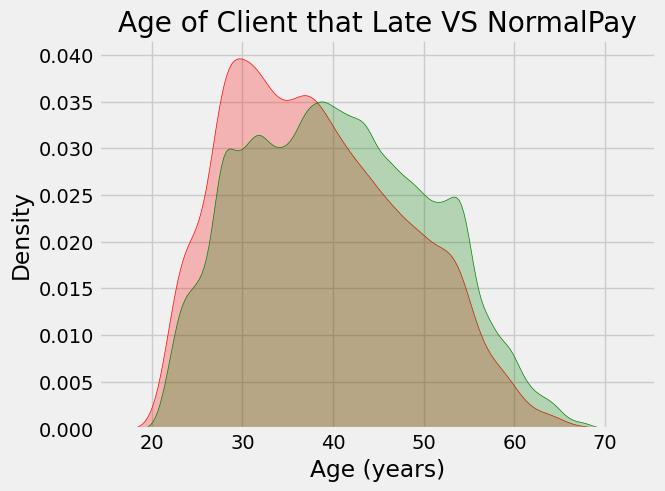

In [ ]:
# Set the style of plots
plt.style.use('fivethirtyeight')

ageLate =  []
ageNorm = []

def ageIdentification(temp,label):
  for i in range(len(dfCleanColumn)):
    if dfCleanColumn["TARGET"][i] == label:
      temp.append(dfCleanColumn["DAYS_BIRTH"][i])

ageIdentification(ageLate,1)
ageIdentification(ageNorm,0)

ageLate_years = abs(np.array(ageLate) / 365)
ageNorm_years = abs(np.array(ageNorm) / 365)

sns.kdeplot(ageLate_years, label='Late', color = 'r',fill=True)
sns.kdeplot(ageNorm_years, label='Normal', color = 'g',  fill=True)
plt.title('Age of Client that Late VS NormalPay')
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.show()

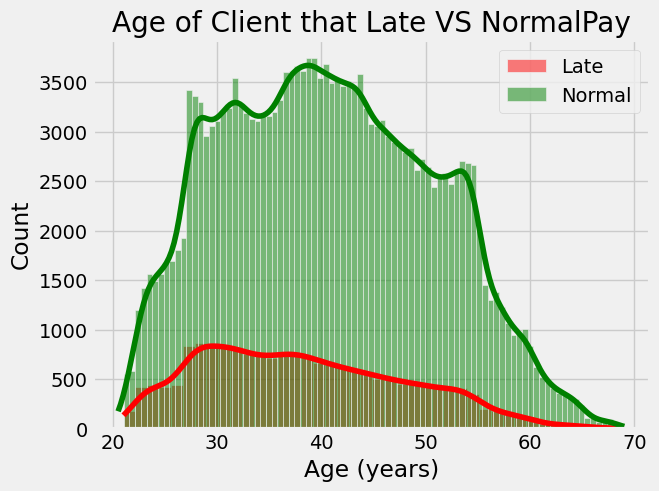

In [ ]:
# Gabungkan histogram dan KDE untuk ageLate_years
sns.histplot(ageLate_years, label='Late', color='r', kde=True, stat="count")

# Gabungkan histogram dan KDE untuk ageNorm_years
sns.histplot(ageNorm_years, label='Normal', color='g', kde=True, stat="count")

plt.title('Age of Client that Late VS NormalPay')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [ ]:
dataAge = dfCleanColumn[['TARGET','DAYS_BIRTH']]
dataAge['years'] = abs(dataAge['DAYS_BIRTH'] / 365)

dataAge['yearsBin'] = pd.cut(dataAge['years'], bins = np.linspace(20, 70, num = 11))
dataAge.head(10)

<ipython-input-28-b7072ad3005b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataAge['years'] = abs(dataAge['DAYS_BIRTH'] / 365)
<ipython-input-28-b7072ad3005b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataAge['yearsBin'] = pd.cut(dataAge['years'], bins = np.linspace(20, 70, num = 11))


,TARGET,DAYS_BIRTH,years,yearsBin
0,1.0,-9461,25.920548,"(25.0, 30.0]"
1,0.0,-16765,45.931507,"(45.0, 50.0]"
2,0.0,-19046,52.180822,"(50.0, 55.0]"
3,0.0,-19005,52.068493,"(50.0, 55.0]"
4,0.0,-19932,54.608219,"(50.0, 55.0]"
5,0.0,-16941,46.413699,"(45.0, 50.0]"
6,0.0,-13778,37.747945,"(35.0, 40.0]"
7,0.0,-18850,51.643836,"(50.0, 55.0]"
8,0.0,-14469,39.641096,"(35.0, 40.0]"
9,0.0,-10197,27.936986,"(25.0, 30.0]"


In [ ]:
ageGroups  = dataAge.groupby('yearsBin').mean()
ageGroups

<ipython-input-29-f09cbec7afca>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ageGroups  = dataAge.groupby('yearsBin').mean()


,TARGET,DAYS_BIRTH,years
yearsBin,,,
"(20.0, 25.0]",0.122751,-8531.550780,23.374112
"(25.0, 30.0]",0.114080,-10154.851998,27.821512
"(30.0, 35.0]",0.104784,-11855.233136,32.480091
"(35.0, 40.0]",0.091021,-13708.417393,37.557308
"(40.0, 45.0]",0.077548,-15497.047974,42.457666
"(45.0, 50.0]",0.074762,-17318.915875,47.449085
"(50.0, 55.0]",0.068979,-19175.614554,52.535930
"(55.0, 60.0]",0.060390,-20892.623714,57.240065
"(60.0, 65.0]",0.048628,-22663.237843,62.091063


<ipython-input-30-d850a2279c7a>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=ageGroups.index.astype(str), y=100 * ageGroups['TARGET'], palette='viridis')


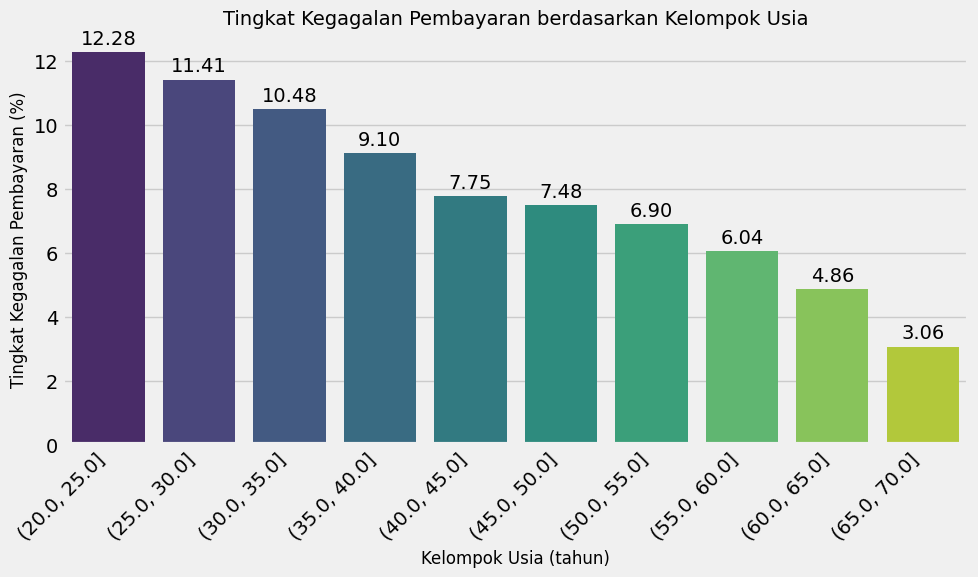

In [ ]:
plt.figure(figsize=(10, 6))  # Sesuaikan ukuran figure agar lebih proporsional

# Gunakan seaborn untuk membuat bar plot dengan detail yang lebih baik
ax = sns.barplot(x=ageGroups.index.astype(str), y=100 * ageGroups['TARGET'], palette='viridis')

# Tambahkan label data pada setiap bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

# Plot labeling
plt.xticks(rotation=45, ha='right')  # Rotasi label sumbu x agar lebih mudah dibaca
plt.xlabel('Kelompok Usia (tahun)', fontsize=12)  # Perbesar ukuran font label sumbu x
plt.ylabel('Tingkat Kegagalan Pembayaran (%)', fontsize=12)  # Perbesar ukuran font label sumbu y
plt.title('Tingkat Kegagalan Pembayaran berdasarkan Kelompok Usia', fontsize=14)  # Perbesar ukuran font judul

plt.tight_layout()  # Sesuaikan layout agar tidak ada elemen yang terpotong
plt.show()

In [ ]:
dfCleanColumn.to_csv("cleanDataset.csv", index=False)

In [ ]:
dfCleanColumn['TARGET'].value_counts()

,count
TARGET,
0.0,192352
1.0,18529


In [ ]:
dfCleanColumn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210881 entries, 0 to 210880
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      210881 non-null  float64
 1   NAME_CONTRACT_TYPE          210881 non-null  int64  
 2   CODE_GENDER                 210881 non-null  int64  
 3   FLAG_OWN_CAR                210881 non-null  int64  
 4   FLAG_OWN_REALTY             210881 non-null  int64  
 5   CNT_CHILDREN                210881 non-null  int64  
 6   AMT_INCOME_TOTAL            210881 non-null  float64
 7   AMT_CREDIT                  210881 non-null  float64
 8   AMT_ANNUITY                 210881 non-null  float64
 9   AMT_GOODS_PRICE             210881 non-null  float64
 10  NAME_INCOME_TYPE            210881 non-null  int64  
 11  NAME_EDUCATION_TYPE         210881 non-null  int64  
 12  NAME_FAMILY_STATUS          210881 non-null  int64  
 13  NAME_HOUSING_T

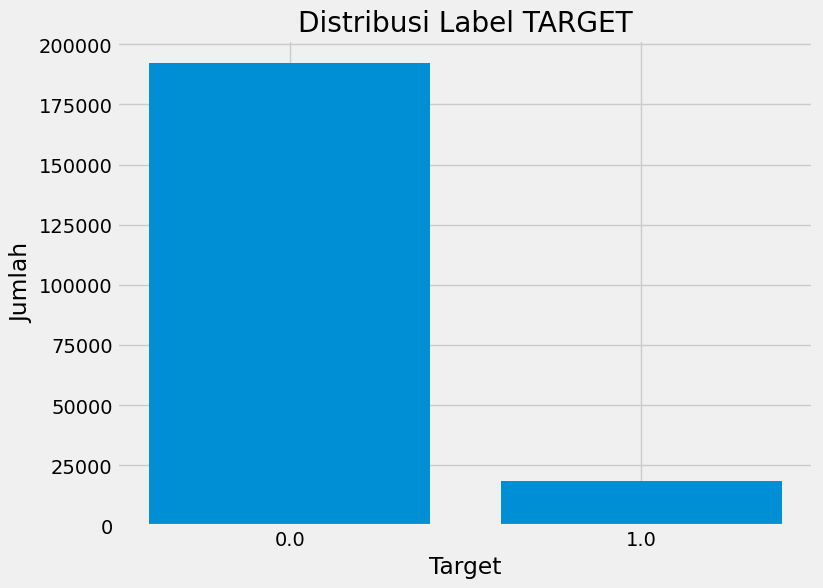

In [ ]:
counts = dfCleanColumn['TARGET'].value_counts()

# Buat plot batang
plt.figure(figsize=(8,6))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Target")
plt.ylabel("Jumlah")
plt.title("Distribusi Label TARGET")
plt.show()

In [ ]:
y = dfCleanColumn["TARGET"]
x = dfCleanColumn.drop(columns="TARGET")

In [ ]:
!pip install imblearn

In [ ]:
from imblearn.under_sampling import NearMiss

nearmiss = NearMiss(version=1)
x, y = nearmiss.fit_resample(x, y)

In [ ]:
# from imblearn.under_sampling import RandomUnderSampler

# rus = RandomUnderSampler(random_state=42)
# x, y = rus.fit_resample(x, y)

In [ ]:
x = np.array(x)
y = np.array(y)

In [ ]:
df = pd.DataFrame(x)
df['TARGET'] = y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37058 entries, 0 to 37057
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       37058 non-null  float64
 1   1       37058 non-null  float64
 2   2       37058 non-null  float64
 3   3       37058 non-null  float64
 4   4       37058 non-null  float64
 5   5       37058 non-null  float64
 6   6       37058 non-null  float64
 7   7       37058 non-null  float64
 8   8       37058 non-null  float64
 9   9       37058 non-null  float64
 10  10      37058 non-null  float64
 11  11      37058 non-null  float64
 12  12      37058 non-null  float64
 13  13      37058 non-null  float64
 14  14      37058 non-null  float64
 15  15      37058 non-null  float64
 16  16      37058 non-null  float64
 17  17      37058 non-null  float64
 18  18      37058 non-null  float64
 19  TARGET  37058 non-null  float64
dtypes: float64(20)
memory usage: 5.7 MB


In [ ]:
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37058 entries, 0 to 37057
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       37058 non-null  float64
 1   1       37058 non-null  float64
 2   2       37058 non-null  float64
 3   3       37058 non-null  float64
 4   4       37058 non-null  float64
 5   5       37058 non-null  float64
 6   6       37058 non-null  float64
 7   7       37058 non-null  float64
 8   8       37058 non-null  float64
 9   9       37058 non-null  float64
 10  10      37058 non-null  float64
 11  11      37058 non-null  float64
 12  12      37058 non-null  float64
 13  13      37058 non-null  float64
 14  14      37058 non-null  float64
 15  15      37058 non-null  float64
 16  16      37058 non-null  float64
 17  17      37058 non-null  float64
 18  18      37058 non-null  float64
 19  TARGET  37058 non-null  float64
dtypes: float64(20)
memory usage: 5.7 MB


In [ ]:
df.to_csv("resampledDataset.csv", index=False)

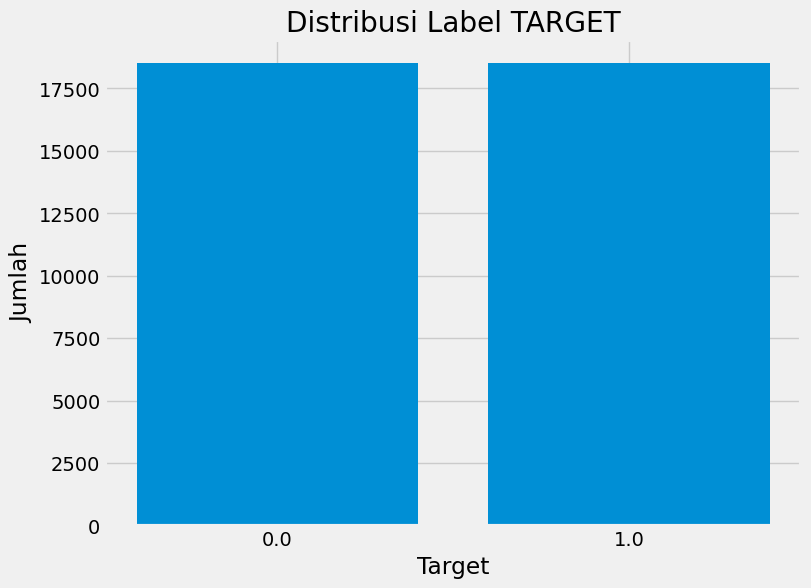

In [ ]:
counts = df['TARGET'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Target")
plt.ylabel("Jumlah")
plt.title("Distribusi Label TARGET")
plt.show()

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,TARGET
0,1.0,0.0,0.0,1.0,0.0,90000.0,180000.0,9000.0,180000.0,1.0,4.0,1.0,1.0,-8248.0,8.0,2.0,0.0,11.0,42.0,0.0
1,1.0,0.0,0.0,1.0,0.0,90000.0,180000.0,9000.0,180000.0,6.0,4.0,3.0,4.0,-8240.0,8.0,1.0,0.0,14.0,35.0,0.0
2,1.0,0.0,0.0,1.0,0.0,90000.0,180000.0,9000.0,180000.0,4.0,2.0,1.0,1.0,-8247.0,11.0,2.0,1.0,15.0,30.0,0.0
3,1.0,0.0,0.0,1.0,0.0,135000.0,180000.0,9000.0,180000.0,1.0,4.0,3.0,5.0,-7843.0,14.0,1.0,6.0,15.0,42.0,0.0
4,1.0,0.0,0.0,0.0,1.0,90000.0,180000.0,9000.0,180000.0,6.0,2.0,3.0,5.0,-8245.0,14.0,2.0,3.0,12.0,42.0,0.0


In [ ]:
# Find correlations with the target and sort
correlations = df.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 15       -0.041700
3        -0.020568
12       -0.014873
11       -0.010977
18        0.000169
16        0.016395
14        0.020184
9         0.020528
5         0.025410
1         0.071129
10        0.109578
8         0.155508
6         0.185271
7         0.296809
TARGET    1.000000
Name: TARGET, dtype: float64

Most Negative Correlations:
 0    -0.457723
13   -0.149583
17   -0.078318
4    -0.054273
2    -0.050426
15   -0.041700
3    -0.020568
12   -0.014873
11   -0.010977
18    0.000169
16    0.016395
14    0.020184
9     0.020528
5     0.025410
1     0.071129
Name: TARGET, dtype: float64


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# dfClean = dfCleanColumn.copy()

# scaler = MinMaxScaler()
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [ ]:
y = df["TARGET"]

In [ ]:
from sklearn.model_selection import train_test_split

xTrain, xTest, yTrain, yTest = train_test_split(x, y, random_state = 42, test_size= 0.2, shuffle=True,stratify = y)

In [ ]:
count = 0
for i in range(len(yTest)):
  if yTest.iloc[i] == 1:
    count = count + 1
print(count)

3706


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
lr = LogisticRegression(max_iter=1000)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

model = GridSearchCV(estimator=lr, param_grid=param_grid, cv=4)
model.fit(xTrain, yTrain)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
24 fits failed out of a total of 48.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

GridSearchCV(cv=4, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2']})

In [ ]:
yPred = model.predict(xTest)
yPred2 = model.predict(xTrain)

print("Logistic Regression Model:")
accuracyLRTest = round(accuracy_score(yTest,yPred),3)
accuracyLRTrain= round(accuracy_score(yTrain,yPred2),3)
print("Accuracy Test:", accuracyLRTest)
print("Accuracy Train:", accuracyLRTrain)
print("Classification Report:")
print(classification_report(yTest, yPred))

Logistic Regression Model:
Accuracy Test: 0.703
Accuracy Train: 0.709
Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.56      0.65      3706
         1.0       0.66      0.84      0.74      3706

    accuracy                           0.70      7412
   macro avg       0.72      0.70      0.70      7412
weighted avg       0.72      0.70      0.70      7412



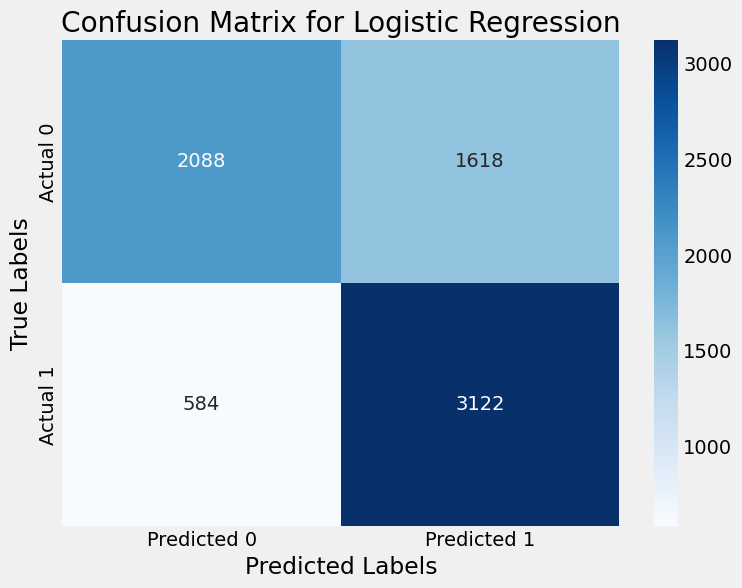

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yTest, yPred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [ ]:
knn_model = KNeighborsClassifier()


param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

model = GridSearchCV(estimator=knn_model, param_grid=param_grid, cv=4)

model.fit(xTrain, yTrain)

GridSearchCV(cv=4, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [ ]:
yPred = model.predict(xTest)
yPred2 = model.predict(xTrain)

print("Logistic Regression Model:")
accuracyKNNTest = round(accuracy_score(yTest,yPred),3)
accuracyKNNTrain= round(accuracy_score(yTrain,yPred2),3)
print("Accuracy Test:", accuracyKNNTest)
print("Accuracy Train:", accuracyKNNTrain)
print("Classification Report:")
print(classification_report(yTest, yPred))

Logistic Regression Model:
Accuracy Test: 0.691
Accuracy Train: 1.0
Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.70      0.69      3706
         1.0       0.70      0.68      0.69      3706

    accuracy                           0.69      7412
   macro avg       0.69      0.69      0.69      7412
weighted avg       0.69      0.69      0.69      7412



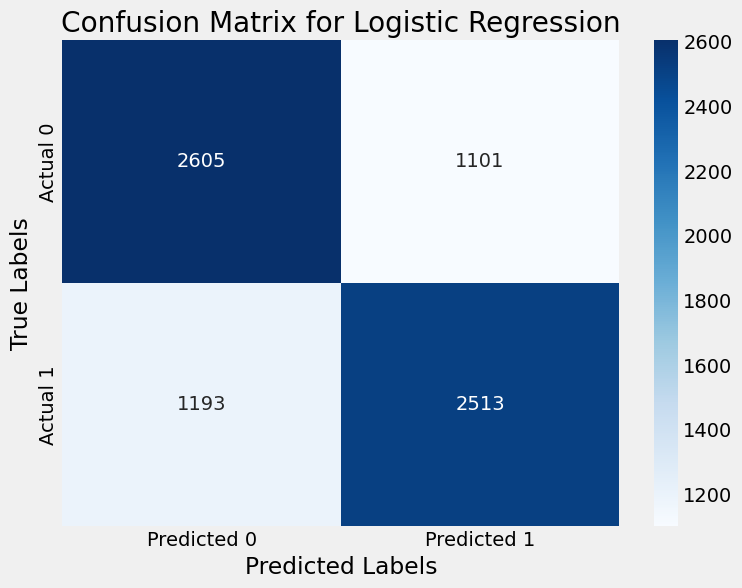

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yTest, yPred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier()

# param_grid = {
#     'n_estimators': [100, 200],
#     'min_samples_split': [2, 5],
#     'max_features': ['auto', 'sqrt'],
# }

param_dist = {
    'n_estimators': [100, 200],  # Increased range for n_estimators
    'max_depth': [None, 10, 20, 30], # Added max_depth
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'] # Added criterion
}

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    cv=5,  # Increased cross-validation folds
    scoring='f1', # Use f1 score for imbalanced dataset
    n_jobs=-1, # Use all available cores for parallel processing
    verbose=1,
    random_state=42
)

# model = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=4)
model = random_search.fit(xTrain, yTrain)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
yPred = model.predict(xTest)
yPred2 = model.predict(xTrain)

print("Logistic Regression Model:")
accuracyRFTest = round(accuracy_score(yTest,yPred),3)
accuracyRFTrain= round(accuracy_score(yTrain,yPred2),3)
print("Accuracy Test:", accuracyRFTest)
print("Accuracy Train:", accuracyRFTrain)
print("Classification Report:")
print(classification_report(yTest, yPred))

Logistic Regression Model:
Accuracy Test: 0.844
Accuracy Train: 0.945
Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.91      0.85      3706
         1.0       0.89      0.78      0.83      3706

    accuracy                           0.84      7412
   macro avg       0.85      0.84      0.84      7412
weighted avg       0.85      0.84      0.84      7412



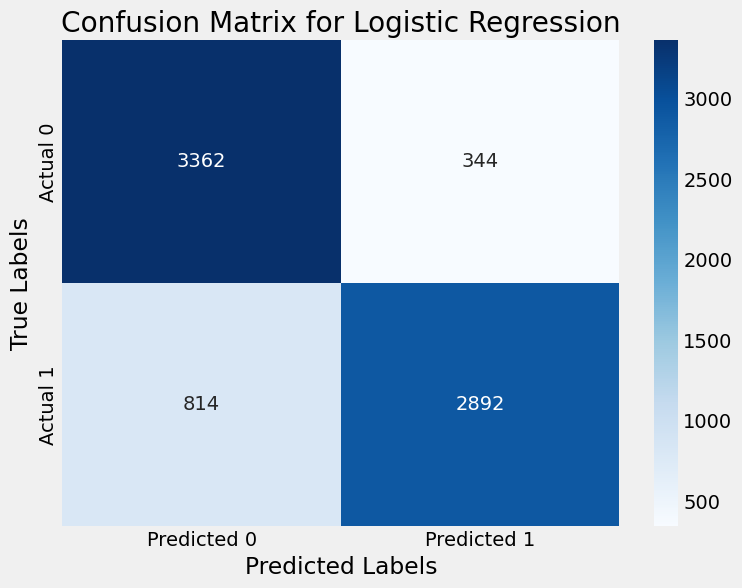

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yTest, yPred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
 from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier,RandomForestClassifier

In [ ]:
clf1 = RandomForestClassifier(n_estimators=50, random_state=42)
clf2 = GradientBoostingClassifier(n_estimators=50, random_state=42)
clf3 = LogisticRegression(max_iter=1000, random_state=42)

# Create a voting classifier (hard voting for classification)
voting_clf = VotingClassifier(estimators=[('rf', clf1), ('gb', clf2), ('lr', clf3)], voting='hard')
voting_clf.fit(xTrain, yTrain)


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(n_estimators=50,
                                                         random_state=42)),
                             ('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42))])

In [ ]:
yPred = voting_clf.predict(xTest)
yPred2 = voting_clf.predict(xTrain)

print("Voting Model:")
accuracyVotTest = round(accuracy_score(yTest,yPred),3)
accuracyVotTrain= round(accuracy_score(yTrain,yPred2),3)
print("Accuracy Test:", accuracyVotTest)
print("Accuracy Train:", accuracyVotTrain)
print("Classification Report:")
print(classification_report(yTest, yPred))

Voting Model:
Accuracy Test: 0.819
Accuracy Train: 0.879
Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.81      0.82      3706
         1.0       0.82      0.82      0.82      3706

    accuracy                           0.82      7412
   macro avg       0.82      0.82      0.82      7412
weighted avg       0.82      0.82      0.82      7412



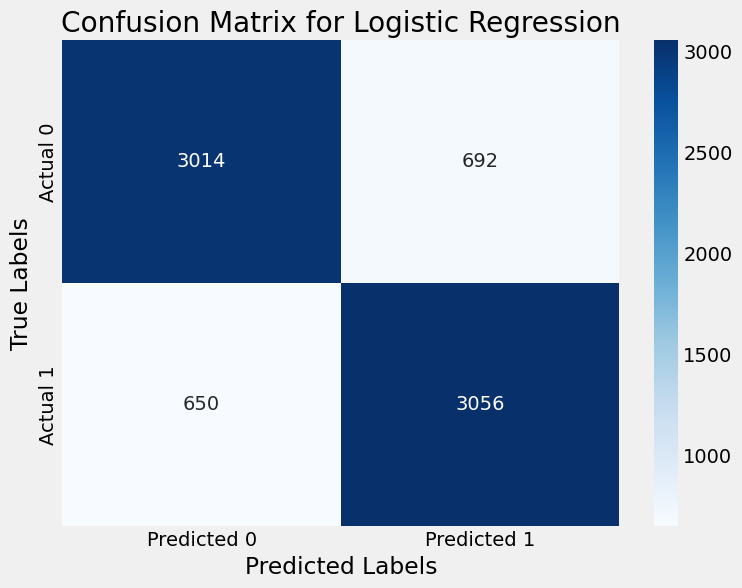

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yTest, yPred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss')

param_distributions_xgb = {
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3],
    'n_estimators': [50, 100, 200, 500, 1000],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'min_child_weight':[1, 3, 5, 7]
}

random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_distributions_xgb, n_iter=50, scoring='roc_auc', cv=5, verbose=2, random_state=42, n_jobs=-1)

random_search.fit(xTrain, yTrain)



Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.001, 0.01, 0.1, 0.2,
                                                          0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [50, 100, 200, 500,
                                                         1000],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
yPred = random_search.predict(xTest)
yPred2 = random_search.predict(xTrain)

print("Voting Model:")
accuracyXGBTest = round(accuracy_score(yTest,yPred),3)
accuracyXGBTrain= round(accuracy_score(yTrain,yPred2),3)
print("Accuracy Test:", accuracyXGBTest)
print("Accuracy Train:", accuracyXGBTrain)
print("Classification Report:")
print(classification_report(yTest, yPred))

Voting Model:
Accuracy Test: 0.862
Accuracy Train: 0.891
Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.92      0.87      3706
         1.0       0.91      0.80      0.85      3706

    accuracy                           0.86      7412
   macro avg       0.87      0.86      0.86      7412
weighted avg       0.87      0.86      0.86      7412



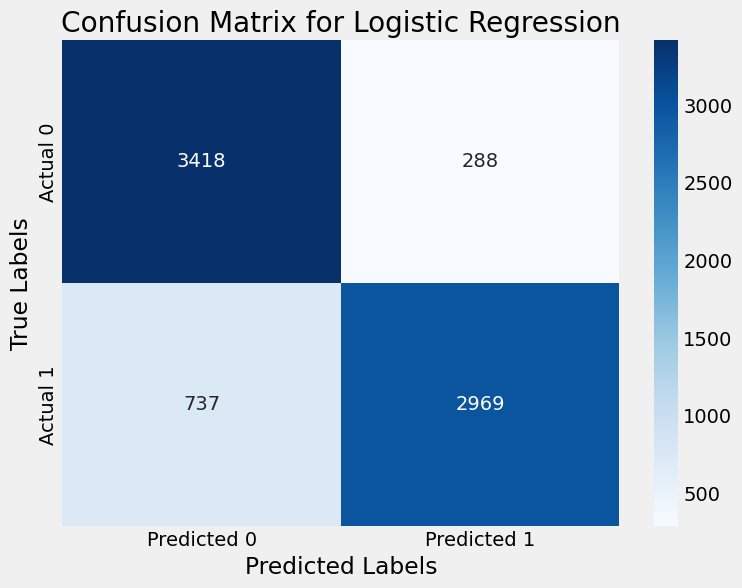

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yTest, yPred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()